<a href="https://colab.research.google.com/github/oszavla/Dirac-Schwarz/blob/main/Persamaan_Dirac_dalam_Ruangwaktu_Datar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import matplotlib.pyplot as plt
# Set up the plot style for a scientific look
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'cm'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Patikel Dirac dalam Pengaruh oleh **Potensial Skalar**

## Kuantisasi Energi Nilai Eigen

### Diurutkan berdasarkan bilangan kuantum utama $n$

In [ ]:
import numpy as np
import pandas as pd
from IPython.display import display

alpha_prime = 1
kappas =  [-10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
N_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Create a dictionary to store epsilon values
epsilon_data = {}

for k in kappas:
    epsilon_data[k] = []
    for n in N_values:
        n_r = n - np.abs(k) # Radial quantum number

        # --- PHYSICAL SELECTION RULES ---
        if n_r < 0:
            # Rule 1: Cannot have negative radial nodes (n >= |k|)
            epsilon = np.nan
        elif n_r == 0 and k > 0:
            # Rule 2: For n_r = 0, kappa MUST be negative (aligned spin)
            epsilon = np.nan
        else:
            # --- EXACT SOMMERFELD FORMULA (Flat Spacetime Baseline) ---
            # Gamma is the relativistic parameter: sqrt(k^2 - alpha'^2)
            gamma_arg = k**2 + alpha_prime**2

            if gamma_arg < 0:
                # Coupling is too strong, vacuum polarization occurs
                epsilon = np.nan
            else:
                gamma = np.sqrt(gamma_arg)
                denominator = n_r + gamma

                # Calculate energy ratio: E / m_0 c^2
                term = 1 - (alpha_prime / denominator)**2
                epsilon = np.sqrt(term)

        epsilon_data[k].append(epsilon)

# Create DataFrame
df_epsilon = pd.DataFrame.from_dict(epsilon_data, orient='index', columns=[f'n={n}' for n in N_values])
df_epsilon.index.name = 'κ'

# Display the table with formatting
print("Exact Dirac-Coulomb Energy Eigenvalues (E/mc^2) - Flat Spacetime Baseline:")
display(df_epsilon.style.format("{:.6f}", na_rep="N/A").background_gradient(cmap='viridis', axis=None))

Exact Dirac-Coulomb Energy Eigenvalues (E/mc^2) - Flat Spacetime Baseline:


,n=1,n=2,n=3,n=4,n=5,n=6,n=7,n=8,n=9,n=10
κ,,,,,,,,,,
-10,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,0.995037
-9,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,0.993884,0.995043
-8,N/A,N/A,N/A,N/A,N/A,N/A,N/A,0.992278,0.993893,0.995049
-7,N/A,N/A,N/A,N/A,N/A,N/A,0.989949,0.992295,0.993905,0.995058
-6,N/A,N/A,N/A,N/A,N/A,0.986394,0.989983,0.992317,0.993921,0.995070
-5,N/A,N/A,N/A,N/A,0.980581,0.986467,0.990029,0.992348,0.993942,0.995085
-4,N/A,N/A,N/A,0.970143,0.980765,0.986574,0.990097,0.992394,0.993974,0.995109
-3,N/A,N/A,0.948683,0.970710,0.981058,0.986745,0.990205,0.992467,0.994026,0.995147
-2,N/A,0.894427,0.951057,0.971737,0.981593,0.987059,0.990405,0.992602,0.994121,0.995217


### Diurutkan Berdasarkan Bilangan Kuantum Radial $n_r$

In [24]:
import numpy as np
import pandas as pd
from IPython.display import display

# Physical Parameters (Toy Model for visible fine-structure)
alpha_prime = 1
kappas =  [-10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
N_r_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
#kappas = [ -5, -4, -3, -2, -1, 1, 2, 3, 4, 5]
#N_r_values = [0, 1, 2, 3, 4, 5]
# Create a dictionary to store epsilon values
epsilon_data = {}
# allowed maximum principal quantum number n
N_MAX = abs(max(kappas))
for k in kappas:
    epsilon_data[k] = []
    for n_r in N_r_values:
    # --- PHYSICAL SELECTION RULES ---
      # principal quantum number
      n = n_r + abs(k)

      # Rule 1: maximum principal quantum number
      if n > N_MAX:
          epsilon = np.nan
      elif n_r == 0 and k > 0:
          # Rule 2: For n_r = 0, kappa MUST be negative (aligned spin)
          epsilon = np.nan
      else:
          gamma_arg = k**2 + alpha_prime**2
          if gamma_arg < 0:
                epsilon = np.nan
          else:
                gamma = np.sqrt(gamma_arg)
                denominator = n_r + gamma
                term = 1 - (alpha_prime / denominator)**2
                epsilon = np.sqrt(term)

      epsilon_data[k].append(epsilon)

# Create DataFrame
df_epsilon = pd.DataFrame.from_dict(epsilon_data, orient='index', columns=[f'n_r={n_r}' for n_r in N_r_values])
df_epsilon.index.name = 'κ'

# Display the table with formatting

display(df_epsilon.style.format("{:.6f}", na_rep="N/A").background_gradient(cmap='viridis', axis=None))



,n_r=0,n_r=1,n_r=2,n_r=3,n_r=4,n_r=5,n_r=6,n_r=7,n_r=8,n_r=9,n_r=10
κ,,,,,,,,,,,
-10,0.995037,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-9,0.993884,0.995043,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-8,0.992278,0.993893,0.995049,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-7,0.989949,0.992295,0.993905,0.995058,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-6,0.986394,0.989983,0.992317,0.993921,0.995070,N/A,N/A,N/A,N/A,N/A,N/A
-5,0.980581,0.986467,0.990029,0.992348,0.993942,0.995085,N/A,N/A,N/A,N/A,N/A
-4,0.970143,0.980765,0.986574,0.990097,0.992394,0.993974,0.995109,N/A,N/A,N/A,N/A
-3,0.948683,0.970710,0.981058,0.986745,0.990205,0.992467,0.994026,0.995147,N/A,N/A,N/A
-2,0.894427,0.951057,0.971737,0.981593,0.987059,0.990405,0.992602,0.994121,0.995217,N/A,N/A


In [27]:
import numpy as np
import pandas as pd
from IPython.display import display

# Physical Parameters (Scalar Coupling)
alpha_prime = 1

data = []

# Iterate through principal quantum number n from 1 to 4
for n in range(1, 11):

    # Generate kappas for the given n: -1, 1, -2, 2, ..., -n
    kappas_for_n = []
    for abs_k in range(1, n + 1):
        kappas_for_n.append(-abs_k)
        if abs_k < n:
            kappas_for_n.append(abs_k)

    for k in kappas_for_n:
        n_r = n - abs(k) # Radial quantum number

        # Orbital angular momentum (l)
        if k < 0:
            l = -k - 1
        else:
            l = k

        # Total angular momentum (j = |k| - 1/2)
        j_num = 2 * abs(k) - 1
        j_str = f"{j_num}/2"

        # Spectroscopic Notation Generation
        l_letters = ['S', 'P', 'D', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N']
        l_char = l_letters[l]
        notasi = f"${n} {l_char}_{{{j_str}}}$"

        # --- EXACT SOMMERFELD FORMULA (Scalar Coupling) ---
        gamma_arg = k**2 + alpha_prime**2
        gamma = np.sqrt(gamma_arg)
        denominator = n_r + gamma

        # Calculate energy ratio: E / m_0 c^2
        term = 1 - (alpha_prime / denominator)**2
        epsilon = np.sqrt(term)

        # Append row data
        data.append({
            "Notasi": notasi,
            "$n$": n,
            "$l$": l,
            "$j$": j_str,
            "$n_r$": n_r,
            "$\\kappa$": k,
            "$E / m_0 c^2$": epsilon
        })

# Create DataFrame
df_epsilon = pd.DataFrame(data)

# Format the dimensionless energy column to 6 decimal places
df_formatted = df_epsilon.copy()
df_formatted['$E / m_0 c^2$'] = df_formatted['$E / m_0 c^2$'].map('{:.10f}'.format)

# Display the table in Jupyter with the index hidden
print("Exact Dirac Energy Eigenvalues (E/mc^2) - Scalar Coupling:")
display(df_formatted.style.hide(axis="index"))

# ---------------------------------------------------------
# OPTIONAL: Automatically generate the LaTeX code
# ---------------------------------------------------------
latex_output = df_formatted.style.hide(axis="index").to_latex(
    column_format=">{\\centering\\arraybackslash}p{2.15cm}cccccc",
    hrules=True
)

# Print LaTeX wrapper
print("\n\\begin{table}[H]")
print("\\begin{center}")
print("\\caption{Klasifikasi keadaan terikat elektron dengan potensial skalar ($\\alpha' = 1$)}")
print("\\small\\setlength{\\tabcolsep}{4pt}")
print(latex_output, end="")
print("\\end{center}\\label{tabel_energi_skalar}")
print("\\end{table}")

Exact Dirac Energy Eigenvalues (E/mc^2) - Scalar Coupling:


Notasi,$n$,$l$,$j$,$n_r$,$\kappa$,$E / m_0 c^2$
$1 S_{1/2}$,1,0,1/2,0,-1,0.7071067812
$2 S_{1/2}$,2,0,1/2,1,-1,0.9101797211
$2 P_{1/2}$,2,1,1/2,1,1,0.9101797211
$2 P_{3/2}$,2,1,3/2,0,-2,0.8944271910
$3 S_{1/2}$,3,0,1/2,2,-1,0.9561451576
$3 P_{1/2}$,3,1,1/2,2,1,0.9561451576
$3 P_{3/2}$,3,1,3/2,1,-2,0.9510565163
$3 D_{3/2}$,3,2,3/2,1,2,0.9510565163
$3 D_{5/2}$,3,2,5/2,0,-3,0.9486832981
$4 S_{1/2}$,4,0,1/2,3,-1,0.9740016487



\begin{table}[H]
\begin{center}
\caption{Klasifikasi keadaan terikat elektron dengan potensial skalar ($\alpha' = 1$)}
\small\setlength{\tabcolsep}{4pt}
\begin{tabular}{>{\centering\arraybackslash}p{2.15cm}cccccc}
\toprule
Notasi & $n$ & $l$ & $j$ & $n_r$ & $\kappa$ & $E / m_0 c^2$ \\
\midrule
$1 S_{1/2}$ & 1 & 0 & 1/2 & 0 & -1 & 0.7071067812 \\
$2 S_{1/2}$ & 2 & 0 & 1/2 & 1 & -1 & 0.9101797211 \\
$2 P_{1/2}$ & 2 & 1 & 1/2 & 1 & 1 & 0.9101797211 \\
$2 P_{3/2}$ & 2 & 1 & 3/2 & 0 & -2 & 0.8944271910 \\
$3 S_{1/2}$ & 3 & 0 & 1/2 & 2 & -1 & 0.9561451576 \\
$3 P_{1/2}$ & 3 & 1 & 1/2 & 2 & 1 & 0.9561451576 \\
$3 P_{3/2}$ & 3 & 1 & 3/2 & 1 & -2 & 0.9510565163 \\
$3 D_{3/2}$ & 3 & 2 & 3/2 & 1 & 2 & 0.9510565163 \\
$3 D_{5/2}$ & 3 & 2 & 5/2 & 0 & -3 & 0.9486832981 \\
$4 S_{1/2}$ & 4 & 0 & 1/2 & 3 & -1 & 0.9740016487 \\
$4 P_{1/2}$ & 4 & 1 & 1/2 & 3 & 1 & 0.9740016487 \\
$4 P_{3/2}$ & 4 & 1 & 3/2 & 2 & -2 & 0.9717365435 \\
$4 D_{3/2}$ & 4 & 2 & 3/2 & 2 & 2 & 0.9717365435 \\
$4 D_{5/2}$ & 4 & 2 

### Konversi $\TeX$

In [22]:
import pandas as pd

# Create the styler object with formatting and gradient
styler = df_epsilon.style.format("{:.6f}", na_rep=" - ").background_gradient(cmap='viridis', axis=None)

# Prepare the LaTeX string with the specific requested wrapper
latex_table_content = styler.to_latex(
    column_format="l" + "c" * len(df_epsilon.columns),
    hrules=True,
    convert_css=True
)

# Custom Header to match requested format exactly
header = r"""\begin{table}[h]
\centering
\caption{Energi (tak-berdimensi $\epsilon=E/m_0c^2$ ) keadaan terikat partikel Dirac yang dipengaruhi oleh potensial Coulomb}
\resizebox{\textwidth}{!}{%
"""

# Using raw strings to avoid SyntaxWarnings with backslashes
final_table = latex_table_content.replace(r"\midrule", r"\midrule")

# Format the index/header area to include the kappa symbol
# We remove the automatically generated header line that has the dummy index name
lines = final_table.split('\n')
# Find the line starting the headers and replace the first empty cell with kappa
for i, line in enumerate(lines):
    if ' & n=0' in line:
        lines[i] = line.replace(' & n=0', r'$\kappa$ & n = 0')
    # Ensure n=1, n=2 etc have spaces
    if 'n=' in lines[i]:
        for n_val in range(1, 6):
            lines[i] = lines[i].replace(f'n={n_val}', f'n = {n_val}')

# Remove the extra line with the '̴' placeholder often generated by pandas index names
lines = [l for l in lines if '̴' not in l]

final_table = '\n'.join(lines)

footer = r"""}
\end{table}"""

print("--- COPY THIS INTO YOUR LATEX PREAMBLE ---")
print("\\usepackage[table]{xcolor}")
print("\\usepackage{booktabs}")
print("\\usepackage{graphicx}")
print("\n--- COPY THIS INTO YOUR LATEX DOCUMENT ---")
print(header + final_table + footer)

--- COPY THIS INTO YOUR LATEX PREAMBLE ---
\usepackage[table]{xcolor}
\usepackage{booktabs}
\usepackage{graphicx}

--- COPY THIS INTO YOUR LATEX DOCUMENT ---
\begin{table}[h]
\centering
\caption{Energi (tak-berdimensi $\epsilon=E/m_0c^2$ ) keadaan terikat partikel Dirac yang dipengaruhi oleh potensial Coulomb}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccc}
\toprule
 & n_r=0 & n_r=1 & n_r=2 & n_r=3 & n_r=4 & n_r=5 \\
κ &  &  &  &  &  &  \\
\midrule
-5 & {\cellcolor[HTML]{F8E621}} \color[HTML]{000000} 0.980581 & {\cellcolor[HTML]{000000}} \color[HTML]{F1F1F1}  -  & {\cellcolor[HTML]{000000}} \color[HTML]{F1F1F1}  -  & {\cellcolor[HTML]{000000}} \color[HTML]{F1F1F1}  -  & {\cellcolor[HTML]{000000}} \color[HTML]{F1F1F1}  -  & {\cellcolor[HTML]{000000}} \color[HTML]{F1F1F1}  -  \\
-4 & {\cellcolor[HTML]{E2E418}} \color[HTML]{000000} 0.970143 & {\cellcolor[HTML]{FBE723}} \color[HTML]{000000} 0.980765 & {\cellcolor[HTML]{000000}} \color[HTML]{F1F1F1}  -  & {\cellcolor[HTML]{000000}} \co

## Fungsi Gelombang Eigen

## Fungsi Gelombang Eigen
Proses ini mengunakan syarat batas $G(0)=F(0)=0$ dan $G(\infty)=F(\infty)=0$

Persamaan radial yang digunakan adalah
\begin{align*}
\frac{\mathrm dG}{\mathrm d\rho} &= -\frac{\kappa}{\rho}G + \left(1 + \epsilon+\frac{Z}{\rho}\alpha-\frac{1}{\rho}\alpha'\right)F,  \\
\frac{\mathrm dF}{\mathrm d\rho} &= +\frac{\kappa}{\rho}F + \left(1 - \epsilon-\frac{Z}{\rho}\alpha-\frac{1}{\rho}\alpha'\right)G,
\end{align*}
dengan
$\alpha'=GM_0m_0/\hbar c$ dan $\alpha = e^2/\hbar c$ adalah *fine structure*

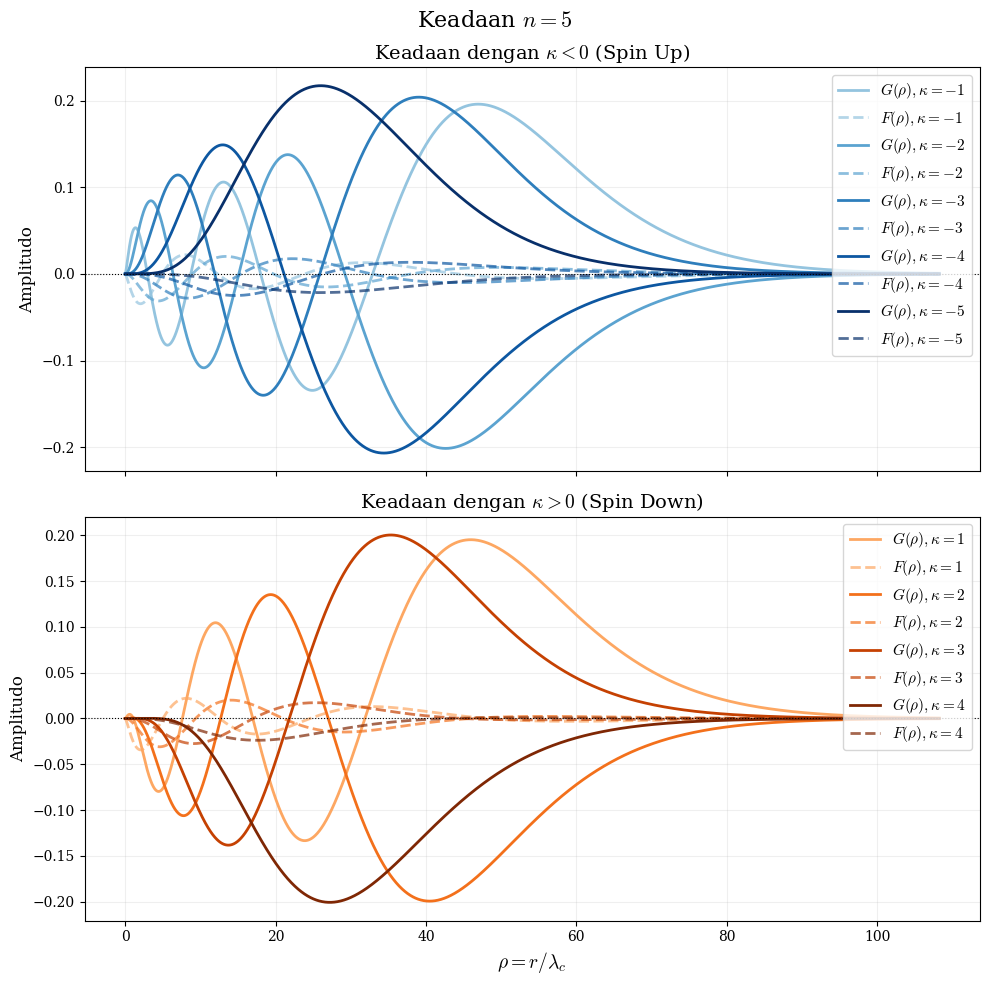

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hyp1f1, gamma, factorial
import matplotlib.cm as cm

# Set up the plot style for a scientific look
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'cm'

# Set to 3 to clearly see multiple positive and negative kappa states
n_val = 5
kappas = [-10, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 10]

alpha = 1 / 137.035999 # fine structure
alpha_prime = 1#3.8239906782121000000000000e+15
Z = 1 # atomic number
lambda_c = 1#3.8615933334959200000000000e-13 # compton wavelength of electron
sqrt_lc = np.sqrt(lambda_c)

def gamm(kappa):
    if kappa**2 + (Z*alpha_prime)**2 < 0:
        return np.nan
    return np.sqrt(kappa**2 + (Z*alpha_prime)**2)

def epsilon(n, kappa):
    denominator = n - abs(kappa) + gamm(kappa)
    if denominator == 0:
        return np.nan
    term0 = 1 - ((Z*alpha_prime) / denominator)**2
    return np.sqrt(term0)

def sigma(n, kappa):
    return 1 - epsilon(n, kappa)**2

def n_prime(n, kappa):
    return Z*alpha_prime/np.sqrt(sigma(n, kappa)) - gamm(kappa)

def G(n, kappa, rho):
    eps = epsilon(n, kappa)
    n_p = int(np.round(n_prime(n, kappa)))
    g = gamm(kappa)
    s = sigma(n, kappa)

    norm1 = (2*np.sqrt(s))**(3/2) / (sqrt_lc * gamma(2*g + 1))
    norm2_num = (1 + eps) * gamma(2*g + n_p + 1)
    norm2_den = (4*(n_p + g)/eps) * ((n_p + g)/eps - kappa) * factorial(n_p)
    norm2 = np.sqrt(norm2_num / norm2_den)

    r1 = (2*np.sqrt(s))**(g - 1)
    r2 = rho**g
    r3 = np.exp(-np.sqrt(s)*rho)

    C_hyp = ((n_p + g)/eps - kappa)
    a1 = -n_p
    a2 = 1 - n_p
    b = 2*g + 1
    z = 2 * np.sqrt(s) * rho

    return norm1 * norm2 * r1 * r2 * r3 * (C_hyp * hyp1f1(a1, b, z) - n_p * hyp1f1(a2, b, z))

def F(n, kappa, rho):
    eps = epsilon(n, kappa)
    n_p = int(np.round(n_prime(n, kappa)))
    g = gamm(kappa)
    s = sigma(n, kappa)

    norm1 = -((2*np.sqrt(s))**(3/2) / (sqrt_lc * gamma(2*g + 1)))
    norm2_num = (1 - eps) * gamma(2*g + n_p + 1)
    norm2_den = (4*(n_p + g)/eps) * ((n_p + g)/eps - kappa) * factorial(n_p)
    norm2 = np.sqrt(norm2_num / norm2_den)

    r1 = (2*np.sqrt(s))**(g - 1)
    r2 = rho**g
    r3 = np.exp(-np.sqrt(s)*rho)

    C_hyp = ((n_p + g)/eps - kappa)
    a1 = -n_p
    a2 = 1 - n_p
    b = 2*g + 1
    z = 2 * np.sqrt(s) * rho

    return norm1 * norm2 * r1 * r2 * r3 * (C_hyp * hyp1f1(a1, b, z) + n_p * hyp1f1(a2, b, z))

# ==========================================
# Filtering and Dynamic Asymptotic X-Axis
# ==========================================

# 1. Filter out unphysical states to prevent crashes
valid_kappas = [k for k in kappas if abs(k) <= n_val and not (abs(k) == n_val and k > 0)]

# 2. Automatically determine the maximum rho needed for the wave to decay
# The decay envelope is exp(-sqrt(sigma)*rho). The smallest decay rate stretches the furthest.
if valid_kappas:
    decay_rates = [np.sqrt(sigma(n_val, k)) for k in valid_kappas]
    slowest_decay = min(decay_rates)
    # Scale the viewing window based on 'n' and the decay rate to ensure it asymptotes to 0
    rho_max = (2 * n_val + 10) / slowest_decay
else:
    rho_max = 20 # Fallback if no valid kappas are passed

rho = np.linspace(1e-5, rho_max, 5000)

# Separate into negative and positive kappa lists
kappas_neg = sorted([k for k in valid_kappas if k < 0], reverse=True)
kappas_pos = sorted([k for k in valid_kappas if k > 0])

# ==========================================
# 2-Panel Plotting
# ==========================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
fig.suptitle(rf'Keadaan $n = {n_val}$', fontsize=16)

# Colors
colors_neg = cm.Blues(np.linspace(0.4, 1, len(kappas_neg))) if kappas_neg else []
colors_pos = cm.Oranges(np.linspace(0.4, 1, len(kappas_pos))) if kappas_pos else []

# Top Plot: Negative Kappa
for i, kappa in enumerate(kappas_neg):
    psi_g = G(n_val, kappa, rho)
    psi_f = F(n_val, kappa, rho)
    ax1.plot(rho, psi_g, color=colors_neg[i], linewidth=2.0, linestyle='-', label=rf'$G(\rho), \kappa={kappa}$')
    ax1.plot(rho, psi_f, color=colors_neg[i], linewidth=2.0, linestyle='--', alpha=0.7, label=rf'$F(\rho), \kappa={kappa}$')

ax1.set_title(r'Keadaan dengan $\kappa < 0$ (Spin Up)', fontsize=14)
ax1.set_ylabel(r'Amplitudo', fontsize=12)
ax1.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax1.grid(alpha=0.2)
if kappas_neg:
    ax1.legend(loc='upper right', fontsize=11, frameon=True)

# Bottom Plot: Positive Kappa
if not kappas_pos:
    ax2.text(0.5, 0.5, rf'Tidak ada keadaan $\kappa$ yang valid untuk $n = {n_val}$',
             ha='center', va='center', transform=ax2.transAxes, fontsize=12, style='italic')
else:
    for i, kappa in enumerate(kappas_pos):
        psi_g = G(n_val, kappa, rho)
        psi_f = F(n_val, kappa, rho)
        ax2.plot(rho, psi_g, color=colors_pos[i], linewidth=2.0, linestyle='-', label=rf'$G(\rho), \kappa={kappa}$')
        ax2.plot(rho, psi_f, color=colors_pos[i], linewidth=2.0, linestyle='--', alpha=0.7, label=rf'$F(\rho), \kappa={kappa}$')
    ax2.legend(loc='upper right', fontsize=11, frameon=True)

ax2.set_title(r'Keadaan dengan $\kappa > 0$ (Spin Down)', fontsize=14)
ax2.set_xlabel(r'$\rho = r/\lambda_c$', fontsize=14)
ax2.set_ylabel(r'Amplitudo', fontsize=12)
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax2.grid(alpha=0.2)

plt.tight_layout()
OUTPUT_DIR = './'
plt.savefig(f'{OUTPUT_DIR}fungsi_gelombang_skalar_n{n_val}.png', dpi=350)
plt.show()

# Patikel Dirac dalam Pengaruh oleh **Potensial Coulomb**

## Energi Ikat
Potensial ini tidak bisa dikomparasikan dengan Potensial Schwarzschild karena tidak ada muatan pada medannya kecuali kita ganti latar belakangnya menjadi lubang hitam bermuatan yakni Lubang Hitam Reissner–Nordström.

### Energi Ikat Diurutkan berdasarkan bilangan kuantum utama $n$ (dalam eV)

In [14]:
import numpy as np
import pandas as pd
from IPython.display import display

# Physical Parameters
kappas = [-10,-9,-8,-7,-6,-5, -4, -3, -2, -1, 1, 2, 3, 4, 5,6,7,8,9,10]
N_values = [1, 2, 3, 4, 5,6,7,8,9,10]
alpha = 1 / 137.035999    # Fine structure constant
Z = 1                     # Atomic number
m0 = 9.10938356e-31       # Electron mass in kg
c = 299792458             # Speed of light in m/s

# E = mc^2 and positive charge conversion
E0_joule = m0 * (c**2)
E0_eV = E0_joule / 1.602176634e-19
E0 = E0_eV

# Create a dictionary to store epsilon values
epsilon_data = {}

for k in kappas:
    epsilon_data[k] = []
    for n in N_values:
        n_r = n - abs(k) # Radial quantum number

        # --- PHYSICAL SELECTION RULES ---
        if n_r < 0:
            epsilon = np.nan
        elif n_r == 0 and k > 0:
            epsilon = np.nan
        else:
            # --- MATHEMATICAL EVALUATION ---
            sqrt_arg = k**2 - (Z*alpha)**2

            if sqrt_arg < 0:
                epsilon = np.nan
            else:
                sqrt_val = np.sqrt(sqrt_arg)
                denominator = n_r + sqrt_val

                if denominator == 0:
                    epsilon = np.nan
                else:
                    ratio_term = (Z*alpha) / denominator
                    term0 = 1 + ratio_term**2

                    # Calculate ratio (E_total / E0)
                    epsilon_ratio = np.sqrt(1 / term0)

                    # Calculate Total Energy
                    E_total = epsilon_ratio * E0

                    # Binding Energy = Total Energy - Rest Mass Energy
                    E_binding = E_total - E0

                    epsilon = E_binding

        epsilon_data[k].append(epsilon)

# Create DataFrame
df_epsilon = pd.DataFrame.from_dict(epsilon_data, orient='index', columns=[f'n={n}' for n in N_values])
df_epsilon.index.name = 'κ'

# Display the table with formatting
display(df_epsilon.style.format("{:.10f}", na_rep="N/A").background_gradient(cmap='viridis', axis=None))

,n=1,n=2,n=3,n=4,n=5,n=6,n=7,n=8,n=9,n=10
κ,,,,,,,,,,
-10,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,-0.1360569474
-9,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,-0.1679715452,-0.1360569554
-8,N/A,N/A,N/A,N/A,N/A,N/A,N/A,-0.2125889962,-0.1679715590,-0.1360569655
-7,N/A,N/A,N/A,N/A,N/A,N/A,-0.2776672781,-0.2125890214,-0.1679715768,-0.1360569784
-6,N/A,N/A,N/A,N/A,N/A,-0.3779360545,-0.2776673284,-0.2125890551,-0.1679716005,-0.1360569957
-5,N/A,N/A,N/A,N/A,-0.5442280069,-0.3779361662,-0.2776673987,-0.2125891023,-0.1679716336,-0.1360570198
-4,N/A,N/A,N/A,-0.8503565156,-0.5442282968,-0.3779363340,-0.2776675044,-0.2125891731,-0.1679716833,-0.1360570560
-3,N/A,N/A,-1.5117458949,-0.8503574589,-0.5442287798,-0.3779366135,-0.2776676805,-0.2125892910,-0.1679717661,-0.1360571164
-2,N/A,-3.4014345527,-1.5117503673,-0.8503593457,-0.5442297458,-0.3779371726,-0.2776680324,-0.2125895269,-0.1679719317,-0.1360572372


### Energi Ikat Diurutkan Berdasarkan Bilangan Kuantum Radial $n_r$ (dalam eV)

In [18]:
import numpy as np
import pandas as pd
from IPython.display import display

# Physical Parameters
kappas = [-10,-9,-8,-7,-6,-5, -4, -3, -2, -1, 1, 2, 3, 4, 5,6,7,8,9,10]
N_r_values = [0, 1, 2, 3, 4, 5,6,7,8,9,10]
#kappas = [ -5, -4, -3, -2, -1, 1, 2, 3, 4, 5]
#N_r_values = [0, 1, 2, 3, 4, 5]
alpha = 1 / 137.035999    # Fine structure constant
Z = 1                     # Atomic number
m0 = 9.10938356e-31       # Electron mass in kg
c = 299792458             # Speed of light in m/s

# E = mc^2 and positive charge conversion
E0_joule = m0 * (c**2)
E0_eV = E0_joule / 1.602176634e-19
E0 = E0_eV

# allowed maximum principal quantum number n
N_MAX = abs(max(kappas))

# Create a dictionary to store epsilon values
epsilon_data = {}

for k in kappas:
    epsilon_data[k] = []
    for n_r in N_r_values:

      # principal quantum number
      n = n_r + abs(k)

      # Rule 1: maximum principal quantum number
      if n > N_MAX:
          epsilon = np.nan
      # Rule 2: For n_r = 0, kappa MUST be negative (aligned spin)
      elif n_r == 0 and k > 0:
          epsilon = np.nan
      else:
          gamma_arg = k**2 - (Z*alpha)**2
          if gamma_arg < 0:
                epsilon = np.nan
          else:
                gamma = np.sqrt(gamma_arg)
                denominator = n_r + gamma
                term = 1 + ((Z*alpha) / denominator)**2

                # Calculate ratio (E_total / E0)
                epsilon_ratio = np.sqrt(1 / term)
                # Calculate Total Energy
                E_total = epsilon_ratio * E0

                # Binding Energy = Total Energy - Rest Mass Energy
                E_binding = E_total - E0

                epsilon = E_binding
      epsilon_data[k].append(epsilon)

# Create DataFrame
df_epsilon = pd.DataFrame.from_dict(epsilon_data, orient='index', columns=[f'n_r={n_r}' for n_r in N_r_values])
df_epsilon.index.name = 'κ'

# Display the table with formatting
display(df_epsilon.style.format("{:.6f}", na_rep="N/A").background_gradient(cmap='viridis', axis=None))

,n_r=0,n_r=1,n_r=2,n_r=3,n_r=4,n_r=5,n_r=6,n_r=7,n_r=8,n_r=9,n_r=10
κ,,,,,,,,,,,
-10,-0.136057,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-9,-0.167972,-0.136057,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-8,-0.212589,-0.167972,-0.136057,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-7,-0.277667,-0.212589,-0.167972,-0.136057,N/A,N/A,N/A,N/A,N/A,N/A,N/A
-6,-0.377936,-0.277667,-0.212589,-0.167972,-0.136057,N/A,N/A,N/A,N/A,N/A,N/A
-5,-0.544228,-0.377936,-0.277667,-0.212589,-0.167972,-0.136057,N/A,N/A,N/A,N/A,N/A
-4,-0.850357,-0.544228,-0.377936,-0.277668,-0.212589,-0.167972,-0.136057,N/A,N/A,N/A,N/A
-3,-1.511746,-0.850357,-0.544229,-0.377937,-0.277668,-0.212589,-0.167972,-0.136057,N/A,N/A,N/A
-2,-3.401435,-1.511750,-0.850359,-0.544230,-0.377937,-0.277668,-0.212590,-0.167972,-0.136057,N/A,N/A


In [19]:
import numpy as np
import pandas as pd
from IPython.display import display

# Physical Parameters
alpha = 1 / 137.035999    # Fine structure constant
Z = 1                     # Atomic number
m0 = 9.10938356e-31       # Electron mass in kg
c = 299792458             # Speed of light in m/s

# E = mc^2 and positive charge conversion
E0_joule = m0 * (c**2)
E0_eV = E0_joule / 1.602176634e-19
E0 = E0_eV

data = []

# Iterate through principal quantum number n from 1 to 4
for n in range(1, 11):

    # Generate kappas in the specific order seen in your table:
    # For a given n, kappa takes values -1, 1, -2, 2, ... up to -n
    kappas_for_n = []
    for abs_k in range(1, n + 1):
        kappas_for_n.append(-abs_k)
        if abs_k < n:
            kappas_for_n.append(abs_k)

    for k in kappas_for_n:
        # Radial quantum number: n = n_r + |k|
        n_r = n - abs(k)

        # Orbital angular momentum (l)
        if k < 0:
            l = -k - 1
        else:
            l = k

        # Total angular momentum (j = |k| - 1/2)
        j_num = 2 * abs(k) - 1
        j_str = f"{j_num}/2"

        # Spectroscopic Notation Generation
        l_letters = ['S', 'P', 'D', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N']
        l_char = l_letters[l]
        notasi = f"${n} {l_char}_{{{j_str}}}$"

        # Calculate Energy
        gamma_arg = k**2 - (Z*alpha)**2
        gamma = np.sqrt(gamma_arg)
        denominator = n_r + gamma
        term = 1 + ((Z*alpha) / denominator)**2

        epsilon_ratio = np.sqrt(1 / term)
        E_total = epsilon_ratio * E0
        E_binding = E_total - E0

        # Append row data
        data.append({
            "Notasi": notasi,
            "$n$": n,
            "$l$": l,
            "$j$": j_str,
            "$n_r$": n_r,
            "$\\kappa$": k,
            "$E_{\\text{ikat}} / \\mathrm{eV}$": E_binding
        })

# Create DataFrame
df_epsilon = pd.DataFrame(data)

# Format the energy column to 3 decimal places
df_formatted = df_epsilon.copy()
df_formatted['$E_{\\text{ikat}} / \\mathrm{eV}$'] = df_formatted['$E_{\\text{ikat}} / \\mathrm{eV}$'].map('{:.15f}'.format)

# Display the table in Jupyter with the index hidden
display(df_formatted.style.hide(axis="index"))

# ---------------------------------------------------------
# OPTIONAL: Automatically generate the LaTeX code for your paper
# ---------------------------------------------------------
latex_output = df_formatted.style.hide(axis="index").to_latex(
    column_format=">{\\centering\\arraybackslash}p{2.15cm}cccccc",
    hrules=True
)

# Print LaTeX wrapper so it perfectly matches your document structure
print("\\begin{table}[H]")
print("\\begin{center}")
print("\\caption{Klasifikasi keadaan terikat elektron menurut persamaan Dirac untuk $Z=1$ (atom hidrogen)}")
print("\\small\\setlength{\\tabcolsep}{4pt}")
print(latex_output, end="")
print("\\end{center}\\label{tabel_energi_ikat_H}")
print("\\end{table}")

Notasi,$n$,$l$,$j$,$n_r$,$\kappa$,$E_{\text{ikat}} / \mathrm{eV}$
$1 S_{1/2}$,1,0,1/2,0,-1,-13.605874063447118
$2 S_{1/2}$,2,0,1/2,1,-1,-3.401479836844373
$2 P_{1/2}$,2,1,1/2,1,1,-3.401479836844373
$2 P_{3/2}$,2,1,3/2,0,-2,-3.401434552739374
$3 S_{1/2}$,3,0,1/2,2,-1,-1.511763784743380
$3 P_{1/2}$,3,1,1/2,2,1,-1.511763784743380
$3 P_{3/2}$,3,1,3/2,1,-2,-1.511750367295463
$3 D_{3/2}$,3,2,3/2,1,2,-1.511750367295463
$3 D_{5/2}$,3,2,5/2,0,-3,-1.511745894851629
$4 S_{1/2}$,4,0,1/2,3,-1,-0.850365006248467


\begin{table}[H]
\begin{center}
\caption{Klasifikasi keadaan terikat elektron menurut persamaan Dirac untuk $Z=1$ (atom hidrogen)}
\small\setlength{\tabcolsep}{4pt}
\begin{tabular}{>{\centering\arraybackslash}p{2.15cm}cccccc}
\toprule
Notasi & $n$ & $l$ & $j$ & $n_r$ & $\kappa$ & $E_{\text{ikat}} / \mathrm{eV}$ \\
\midrule
$1 S_{1/2}$ & 1 & 0 & 1/2 & 0 & -1 & -13.605874063447118 \\
$2 S_{1/2}$ & 2 & 0 & 1/2 & 1 & -1 & -3.401479836844373 \\
$2 P_{1/2}$ & 2 & 1 & 1/2 & 1 & 1 & -3.401479836844373 \\
$2 P_{3/2}$ & 2 & 1 & 3/2 & 0 & -2 & -3.401434552739374 \\
$3 S_{1/2}$ & 3 & 0 & 1/2 & 2 & -1 & -1.511763784743380 \\
$3 P_{1/2}$ & 3 & 1 & 1/2 & 2 & 1 & -1.511763784743380 \\
$3 P_{3/2}$ & 3 & 1 & 3/2 & 1 & -2 & -1.511750367295463 \\
$3 D_{3/2}$ & 3 & 2 & 3/2 & 1 & 2 & -1.511750367295463 \\
$3 D_{5/2}$ & 3 & 2 & 5/2 & 0 & -3 & -1.511745894851629 \\
$4 S_{1/2}$ & 4 & 0 & 1/2 & 3 & -1 & -0.850365006248467 \\
$4 P_{1/2}$ & 4 & 1 & 1/2 & 3 & 1 & -0.850365006248467 \\
$4 P_{3/2}$ & 4 & 1 & 3/2 & 2

## Fungsi Gelombang Eigen
Proses ini mengunakan syarat batas $G(0)=F(0)=0$ dan $G(\infty)=F(\infty)=0$

Persamaan radial yang digunakan adalah
\begin{align*}
\frac{\mathrm dG}{\mathrm d\rho} &= -\frac{\kappa}{\rho}G + \left(1 + \epsilon+\frac{Z\alpha}{\rho}\right)F,  \\
\frac{\mathrm dF}{\mathrm d\rho} &= +\frac{\kappa}{\rho}F + \left(1 - \epsilon-\frac{Z\alpha}{\rho}\right)G,
\end{align*}
dengan
$\alpha = e^2/\hbar c$ adalah *fine structure*

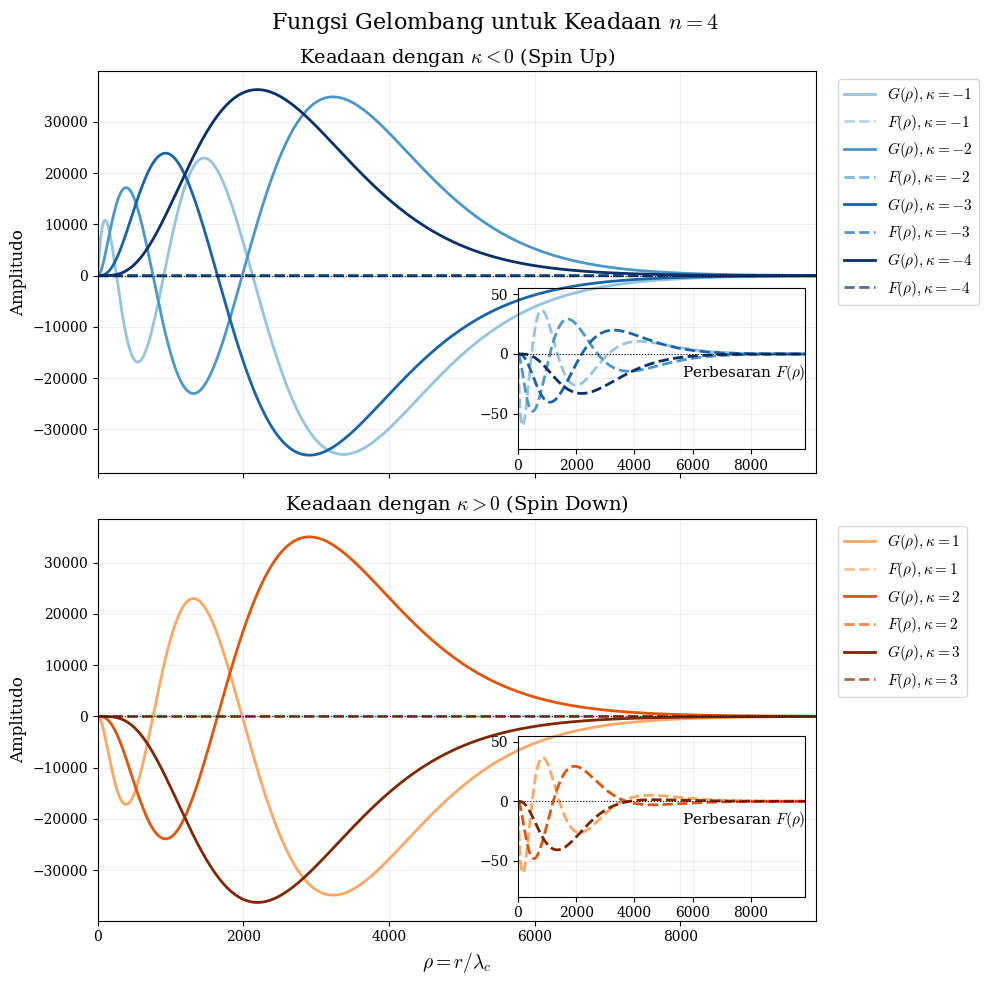

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hyp1f1, gamma, factorial
import matplotlib.cm as cm

# Set up the plot style for a scientific look
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'cm'

# Set to 3 to clearly see multiple positive and negative kappa states
n_val = 4 #n = 1, 2, 3,... (pricipal quantum number)
kappas = [-10, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 10]

alpha = 1 / 137.035999 # fine structure
Z = 1 # atomic number
lambda_c =  3.8615933334959200000000000e-13 # compton wavelength of electron
sqrt_lc = np.sqrt(lambda_c)

def gamm(kappa):
    if kappa**2 - (Z*alpha)**2 < 0:
        return np.nan
    return np.sqrt(kappa**2 - (Z*alpha)**2)

def epsilon(n, kappa):
    denominator = n - abs(kappa) + gamm(kappa)
    if denominator == 0:
        return np.nan
    term0 = 1 + ((Z*alpha) / denominator)**2
    return np.sqrt(1/term0)

def sigma(n, kappa):
    return 1 - epsilon(n, kappa)**2

def n_prime(n, kappa):
    return (Z*alpha*epsilon(n, kappa))/np.sqrt(sigma(n, kappa)) - gamm(kappa)

def G(n, kappa, rho):
    eps = epsilon(n, kappa)
    n_p = int(np.round(n_prime(n, kappa)))
    g = gamm(kappa)
    s = sigma(n, kappa)

    norm1 = (2*np.sqrt(s))**(3/2) / (sqrt_lc * gamma(2*g + 1))
    norm2_num = (1 + eps) * gamma(2*g + n_p + 1)
    norm2_den = (4*(n_p + g)/eps) * ((n_p + g)/eps - kappa) * factorial(n_p)
    norm2 = np.sqrt(norm2_num / norm2_den)

    r1 = (2*np.sqrt(s))**(g - 1)
    r2 = rho**g
    r3 = np.exp(-np.sqrt(s)*rho)

    C_hyp = ((n_p + g)/eps - kappa)
    a1 = -n_p
    a2 = 1 - n_p
    b = 2*g + 1
    z = 2 * np.sqrt(s) * rho

    return norm1 * norm2 * r1 * r2 * r3 * (C_hyp * hyp1f1(a1, b, z) - n_p * hyp1f1(a2, b, z))

def F(n, kappa, rho):
    eps = epsilon(n, kappa)
    n_p = int(np.round(n_prime(n, kappa)))
    g = gamm(kappa)
    s = sigma(n, kappa)

    norm1 = -((2*np.sqrt(s))**(3/2) / (sqrt_lc * gamma(2*g + 1)))
    norm2_num = (1 - eps) * gamma(2*g + n_p + 1)
    norm2_den = (4*(n_p + g)/eps) * ((n_p + g)/eps - kappa) * factorial(n_p)
    norm2 = np.sqrt(norm2_num / norm2_den)

    r1 = (2*np.sqrt(s))**(g - 1)
    r2 = rho**g
    r3 = np.exp(-np.sqrt(s)*rho)

    C_hyp = ((n_p + g)/eps - kappa)
    a1 = -n_p
    a2 = 1 - n_p
    b = 2*g + 1
    z = 2 * np.sqrt(s) * rho

    return norm1 * norm2 * r1 * r2 * r3 * (C_hyp * hyp1f1(a1, b, z) + n_p * hyp1f1(a2, b, z))

# ==========================================
# Filtering and Dynamic Asymptotic X-Axis
# ==========================================

# 1. Filter out unphysical states to prevent crashes
valid_kappas = [k for k in kappas if abs(k) <= n_val and not (abs(k) == n_val and k > 0)]

# 2. Automatically determine the maximum rho needed for the wave to decay
# The decay envelope is exp(-sqrt(sigma)*rho). The smallest decay rate stretches the furthest.
if valid_kappas:
    decay_rates = [np.sqrt(sigma(n_val, k)) for k in valid_kappas]
    slowest_decay = min(decay_rates)
    # Scale the viewing window based on 'n' and the decay rate to ensure it asymptotes to 0
    rho_max = (2 * n_val + 10) / slowest_decay
else:
    rho_max = 20 # Fallback if no valid kappas are passed

rho = np.linspace(1e-5, rho_max, 5000)

# Separate into negative and positive kappa lists
kappas_neg = sorted([k for k in valid_kappas if k < 0], reverse=True)
kappas_pos = sorted([k for k in valid_kappas if k > 0])
# ==========================================
# 2-Panel Plotting (With Insets for F(rho))
# ==========================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
fig.suptitle(rf'Fungsi Gelombang untuk Keadaan $n = {n_val}$', fontsize=16)

# Colors
colors_neg = cm.Blues(np.linspace(0.4, 1, len(kappas_neg))) if kappas_neg else []
colors_pos = cm.Oranges(np.linspace(0.4, 1, len(kappas_pos))) if kappas_pos else []

# ------------------------------------------
# Top Plot: Negative Kappa
# ------------------------------------------
# Create inset for ax1 [x0, y0, width, height] in relative axes coordinates
axins1 = ax1.inset_axes([0.585, 0.06, 0.4, 0.4], facecolor='none')

for i, kappa in enumerate(kappas_neg):
    psi_g = G(n_val, kappa, rho)
    psi_f = F(n_val, kappa, rho)

    # Main plot
    ax1.plot(rho, psi_g, color=colors_neg[i], linewidth=2.0, linestyle='-', label=rf'$G(\rho), \kappa={kappa}$')
    ax1.plot(rho, psi_f, color=colors_neg[i], linewidth=2.0, linestyle='--', alpha=0.7, label=rf'$F(\rho), \kappa={kappa}$')

    # Inset plot (only plotting F to keep it clean)
    axins1.plot(rho, psi_f, color=colors_neg[i], linewidth=2.0, linestyle='--')

ax1.set_title(r'Keadaan dengan $\kappa < 0$ (Spin Up)', fontsize=14)
ax1.set_ylabel(r'Amplitudo', fontsize=12)
ax1.set_xlim(-0.5, max(rho))
ax1.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax1.grid(alpha=0.2)
if kappas_neg:
    # Moved legend to top left to avoid covering the inset
    ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=11, frameon=True)

# Format the inset
axins1.set_title(r'Perbesaran $F(\rho)$', loc='right', y=0.4, fontsize=11)
axins1.set_xlim(-0.5, max(rho) ) # Focus on the active wave region
axins1.set_ylim(-80, 55)         # Constrain y-axis to F(rho) scale
axins1.axhline(0, color='black', linewidth=0.8, linestyle=':')
axins1.grid(alpha=0.2)


# ------------------------------------------
# Bottom Plot: Positive Kappa
# ------------------------------------------
if not kappas_pos:
    ax2.text(0.5, 0.5, rf'No valid positive $\kappa$ states exist for $n = {n_val}$',
             ha='center', va='center', transform=ax2.transAxes, fontsize=12, style='italic')
else:
    # Create inset for ax2
    axins2 = ax2.inset_axes([0.585, 0.06, 0.4, 0.4], facecolor='none')

    for i, kappa in enumerate(kappas_pos):
        psi_g = G(n_val, kappa, rho)
        psi_f = F(n_val, kappa, rho)

        # Main plot
        ax2.plot(rho, psi_g, color=colors_pos[i], linewidth=2.0, linestyle='-', label=rf'$G(\rho), \kappa={kappa}$')
        ax2.plot(rho, psi_f, color=colors_pos[i], linewidth=2.0, linestyle='--', alpha=0.7, label=rf'$F(\rho), \kappa={kappa}$')

        # Inset plot
        axins2.plot(rho, psi_f, color=colors_pos[i], linewidth=2.0, linestyle='--')

    ax2.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=11, frameon=True)

    # Format the inset
    axins2.set_title(r'Perbesaran $F(\rho)$', loc='right', y=0.4, fontsize=11)
    axins2.set_xlim(-0.5, max(rho))
    axins2.set_ylim(-80, 55)
    axins2.axhline(0, color='black', linewidth=0.8, linestyle=':')
    axins2.grid(alpha=0.2)

ax2.set_title(r'Keadaan dengan $\kappa > 0$ (Spin Down)', fontsize=14)
ax2.set_xlabel(r'$\rho = r/\lambda_c$', fontsize=14)
ax2.set_xlim(-0.5, max(rho))
ax2.set_ylabel(r'Amplitudo', fontsize=12)
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax2.grid(alpha=0.2)
plt.tight_layout()
OUTPUT_DIR = './'
plt.savefig(f'{OUTPUT_DIR}fungsi_gelombang_n{n_val}.png', dpi=350)
plt.show()

# Partikel Dirac dalam Pengaruh Potensial Kotak Persegi Berhingga


## Klasifikasi Potensial

### $|V_0|<2m_0c^2$

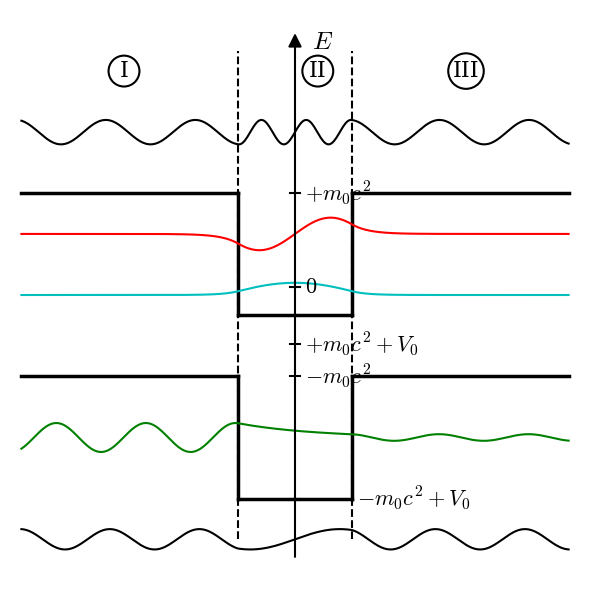

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- HELPER FUNCTIONS FOR PHYSICS-ACCURATE WAVEFUNCTIONS ---

def continuous_scattering_wave(x, y_offset, amplitude, k_outer, k_inner, L, phase_shift=0):
    """Continuous wave with different frequencies inside/outside, constant amplitude."""
    phase = np.piecewise(x,
                         [x < -L, (x >= -L) & (x <= L), x > L],
                         [lambda x: -k_inner * L + k_outer * (x + L),
                          lambda x: k_inner * x,
                          lambda x: k_inner * L + k_outer * (x - L)])
    return y_offset + amplitude * np.sin(phase + phase_shift)

def tunneling_wave(x, y_offset, amp_in, amp_out, k, L):
    """Tunneling wave: incident from left, decays inside barrier, smaller amplitude on right."""
    # Calculate decay constant based on the amplitude drop across 2L
    kappa = -np.log(amp_out / amp_in) / (2 * L)

    # Calculate phase shift to ensure the slope is continuous at the boundaries
    phi = np.arctan2(k, -kappa)
    A_left = amp_in / np.sin(phi)
    A_right = amp_out / np.sin(phi)

    y = np.piecewise(x,
        [x < -L, (x >= -L) & (x <= L), x > L],
        [lambda x: A_left * np.sin(k * (x + L) + phi),  # Incoming wave
         lambda x: amp_in * np.exp(-kappa * (x + L)),   # Exponential decay inside
         lambda x: A_right * np.sin(k * (x - L) + phi)] # Transmitted wave
    )
    return y_offset + y

def bound_state_odd(x, y_offset, A, k_in, L):
    """Antisymmetric bound state with exponential tails."""
    alpha = -k_in / np.tan(k_in * L) # Ensures slope matches at boundary
    C = A * np.sin(k_in * L)         # Amplitude at boundary

    y = np.piecewise(x,
        [x < -L, (x >= -L) & (x <= L), x > L],
        [lambda x: -C * np.exp(alpha * (x + L)),  # Left tail (negative)
         lambda x: A * np.sin(k_in * x),          # Inner oscillating part
         lambda x: C * np.exp(-alpha * (x - L))]  # Right tail (positive)
    )
    return y_offset + y

def bound_state_even(x, y_offset, A, k_in, L):
    """Symmetric bound state with exponential tails."""
    alpha = k_in * np.tan(k_in * L)  # Ensures slope matches at boundary
    C = A * np.cos(k_in * L)         # Amplitude at boundary

    y = np.piecewise(x,
        [x < -L, (x >= -L) & (x <= L), x > L],
        [lambda x: C * np.exp(alpha * (x + L)),   # Left tail
         lambda x: A * np.cos(k_in * x),          # Inner oscillating part
         lambda x: C * np.exp(-alpha * (x - L))]  # Right tail
    )
    return y_offset + y

# -----------------------------------------------------------

# 1. Setup the figure
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-5, 5)
ax.set_ylim(-6, 8)
ax.axis('off')

# 2. Define key coordinates
L = 1
x_all = np.linspace(-4.8, 4.8, 500)

# 3. Draw standard lines (Axes and Region Boundaries)
ax.annotate('', xy=(0, 7.5), xytext=(0, -5.5),
            arrowprops=dict(arrowstyle="-|>", color='black', lw=1.5, mutation_scale=20))
ax.text(0.3, 7.2, r'$E$', fontsize=18, va='center')

ax.plot([-L, -L], [-5, 7], 'k--', lw=1.5)
ax.plot([L, L], [-5, 7], 'k--', lw=1.5)

bbox_props = dict(boxstyle="circle,pad=0.2", edgecolor="black", facecolor="none", lw=1.5)
ax.text(-3, 6.5, 'I', fontsize=16, ha='center', va='center', bbox=bbox_props)
ax.text(0.4, 6.5, 'II', fontsize=16, ha='center', va='center', bbox=bbox_props)
ax.text(3, 6.5, 'III', fontsize=16, ha='center', va='center', bbox=bbox_props)

# 4. Draw the Potential Wells
top_well_outer, top_well_inner = 3.5, 0.5
ax.plot([-4.8, -L], [top_well_outer, top_well_outer], 'k-', lw=2.5)
ax.plot([L, 4.8], [top_well_outer, top_well_outer], 'k-', lw=2.5)
ax.plot([-L, L], [top_well_inner, top_well_inner], 'k-', lw=2.5)
ax.plot([-L, -L], [top_well_inner, top_well_outer], 'k-', lw=2.5)
ax.plot([L, L], [top_well_inner, top_well_outer], 'k-', lw=2.5)

bot_well_outer, bot_well_inner = -1.0, -4.0
ax.plot([-4.8, -L], [bot_well_outer, bot_well_outer], 'b-', lw=2.5)
ax.plot([L, 4.8], [bot_well_outer, bot_well_outer], 'b-', lw=2.5)
ax.plot([-L, L], [bot_well_inner, bot_well_inner], 'b-', lw=2.5)
ax.plot([-L, -L], [bot_well_inner, bot_well_outer], 'b-', lw=2.5)
ax.plot([L, L], [bot_well_inner, bot_well_outer], 'b-', lw=2.5)

# 5. Draw Y-Axis Ticks and Labels
tick_len = 0.08
labels = [
    (top_well_outer, r'$+m_0c^2$'),
    (1.2, r'$0$'),
    (-0.2, r'$+m_0c^2+V_0$'),
    (bot_well_outer, r'$-m_0c^2$'),
    (bot_well_inner, r'$-m_0c^2+V_0$')
]

for y, text in labels:
    ax.plot([-tick_len, tick_len], [y, y], 'k-', lw=1.5)
    x_pos = tick_len + 0.1
    if y == bot_well_inner: # Check for the specific label
        x_pos = tick_len + 1 # Adjust x-position for better visibility
    ax.text(x_pos, y, text, fontsize=16, va='center')

# 6. Draw Wavefunctions

# Wave 1: Top continuous wave
y_wave1 = continuous_scattering_wave(x_all, y_offset=5.0, amplitude=0.3, k_outer=4, k_inner=8, L=L)
ax.plot(x_all, y_wave1, 'k-', lw=1.5)

# Wave 2: Upper bound state (Antisymmetric with decaying tails)
# k_in is chosen so the sine wave doesn't exactly hit 0 at the boundary, ensuring a smooth tail
y_wave2 = bound_state_odd(x_all, y_offset=2.5, A=0.4, k_in=(0.8 * np.pi / L), L=L)
ax.plot(x_all, y_wave2, 'r-', lw=1.5)

# Wave 3: Lower bound state (Symmetric with decaying tails)
y_wave3 = bound_state_even(x_all, y_offset=1.0, A=0.3, k_in=(0.4 * np.pi / L), L=L)
ax.plot(x_all, y_wave3, 'c-', lw=1.5)

# Wave 4: Middle tunneling wave (Decays inside barrier)
y_wave4 = tunneling_wave(x_all, y_offset=-2.5, amp_in=0.35, amp_out=0.08, k=4, L=L)
ax.plot(x_all, y_wave4, 'g-', lw=1.5)

# Wave 5: Bottom continuous wave
y_wave5 = continuous_scattering_wave(x_all, y_offset=-5.0, amplitude=0.25, k_outer=4, k_inner=2, L=L)
ax.plot(x_all, y_wave5, 'k-', lw=1.5)

# 7. Final rendering adjustments
plt.tight_layout()
plt.show()

### $|V_0|>2m_0c^2$

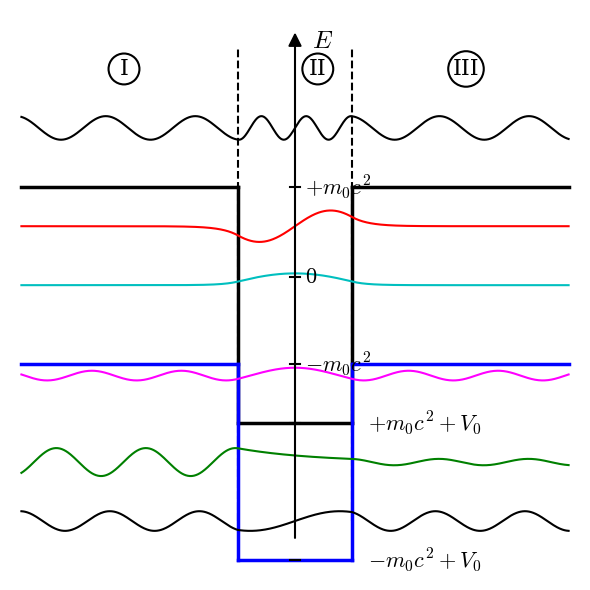

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- HELPER FUNCTIONS FOR PHYSICS-ACCURATE WAVEFUNCTIONS ---

def continuous_scattering_wave(x, y_offset, amplitude, k_outer, k_inner, L, phase_shift=0):
    """Continuous wave with different frequencies inside/outside, constant amplitude."""
    phase = np.piecewise(x,
                         [x < -L, (x >= -L) & (x <= L), x > L],
                         [lambda x: -k_inner * L + k_outer * (x + L),
                          lambda x: k_inner * x,
                          lambda x: k_inner * L + k_outer * (x - L)])
    return y_offset + amplitude * np.sin(phase + phase_shift)

def tunneling_wave(x, y_offset, amp_in, amp_out, k, L):
    """Tunneling wave: incident from left, decays inside barrier, smaller amplitude on right."""
    kappa = -np.log(amp_out / amp_in) / (2 * L)
    phi = np.arctan2(k, -kappa)
    A_left = amp_in / np.sin(phi)
    A_right = amp_out / np.sin(phi)

    y = np.piecewise(x,
        [x < -L, (x >= -L) & (x <= L), x > L],
        [lambda x: A_left * np.sin(k * (x + L) + phi),
         lambda x: amp_in * np.exp(-kappa * (x + L)),
         lambda x: A_right * np.sin(k * (x - L) + phi)]
    )
    return y_offset + y

def bound_state_odd(x, y_offset, A, k_in, L):
    """Antisymmetric bound state with exponential tails."""
    alpha = -k_in / np.tan(k_in * L)
    C = A * np.sin(k_in * L)

    y = np.piecewise(x,
        [x < -L, (x >= -L) & (x <= L), x > L],
        [lambda x: -C * np.exp(alpha * (x + L)),
         lambda x: A * np.sin(k_in * x),
         lambda x: C * np.exp(-alpha * (x - L))]
    )
    return y_offset + y

def bound_state_even(x, y_offset, A, k_in, L):
    """Symmetric bound state with exponential tails."""
    alpha = k_in * np.tan(k_in * L)
    C = A * np.cos(k_in * L)

    y = np.piecewise(x,
        [x < -L, (x >= -L) & (x <= L), x > L],
        [lambda x: C * np.exp(alpha * (x + L)),
         lambda x: A * np.cos(k_in * x),
         lambda x: C * np.exp(-alpha * (x - L))]
    )
    return y_offset + y

def quasibound_state(x, y_offset, A_in, k_in, k_out, L):
    """
    Quasibound state (resonance): High amplitude standing wave inside,
    matching perfectly to a lower amplitude oscillating wave outside.
    """
    # Calculate value and slope of the inside wave at the right boundary (x = L)
    val_L = A_in * np.cos(k_in * L)
    slope_L = -A_in * k_in * np.sin(k_in * L)

    # Calculate required phase and amplitude for the outside wave to match perfectly
    angle = np.arctan2(-slope_L, k_out * val_L)
    phi = angle - k_out * L

    # Avoid division by zero for amplitude calculation
    if np.abs(np.cos(angle)) > 1e-4:
        A_out = val_L / np.cos(angle)
    else:
        A_out = -slope_L / (k_out * np.sin(angle))

    y = np.piecewise(x,
        [x < -L, (x >= -L) & (x <= L), x > L],
        [lambda x: A_out * np.cos(-k_out * x + phi), # Left oscillating wave
         lambda x: A_in * np.cos(k_in * x),          # Inner standing wave
         lambda x: A_out * np.cos(k_out * x + phi)]  # Right oscillating wave
    )
    return y_offset + y


# -----------------------------------------------------------

# 1. Setup the figure
fig, ax = plt.subplots(figsize=(6, 6)) # Slightly larger for better visibility
ax.set_xlim(-5, 5)
ax.set_ylim(-6.5, 8)
ax.axis('off')

# 2. Define key coordinates
L = 1
x_all = np.linspace(-4.8, 4.8, 800) # Increased resolution for smooth matching

# 3. Draw standard lines (Axes and Region Boundaries)
ax.annotate('', xy=(0, 7.5), xytext=(0, -5.5),
            arrowprops=dict(arrowstyle="-|>", color='black', lw=1.5, mutation_scale=20))
ax.text(0.3, 7.2, r'$E$', fontsize=18, va='center')

ax.plot([-L, -L], [-5, 7], 'k--', lw=1.5)
ax.plot([L, L], [-5, 7], 'k--', lw=1.5)

bbox_props = dict(boxstyle="circle,pad=0.2", edgecolor="black", facecolor="none", lw=1.5)
ax.text(-3, 6.5, 'I', fontsize=16, ha='center', va='center', bbox=bbox_props)
ax.text(0.4, 6.5, 'II', fontsize=16, ha='center', va='center', bbox=bbox_props)
ax.text(3, 6.5, 'III', fontsize=16, ha='center', va='center', bbox=bbox_props)

# 4. Draw the Potential Wells
top_well_outer, top_well_inner = 3.5, -2.5
ax.plot([-4.8, -L], [top_well_outer, top_well_outer], 'k-', lw=2.5)
ax.plot([L, 4.8], [top_well_outer, top_well_outer], 'k-', lw=2.5)
ax.plot([-L, L], [top_well_inner, top_well_inner], 'k-', lw=2.5)
ax.plot([-L, -L], [top_well_inner, top_well_outer], 'k-', lw=2.5)
ax.plot([L, L], [top_well_inner, top_well_outer], 'k-', lw=2.5)

bot_well_outer, bot_well_inner = -1.0, -6.0
ax.plot([-4.8, -L], [bot_well_outer, bot_well_outer], 'b-', lw=2.5)
ax.plot([L, 4.8], [bot_well_outer, bot_well_outer], 'b-', lw=2.5)
ax.plot([-L, L], [bot_well_inner, bot_well_inner], 'b-', lw=2.5)
ax.plot([-L, -L], [bot_well_inner, bot_well_outer], 'b-', lw=2.5)
ax.plot([L, L], [bot_well_inner, bot_well_outer], 'b-', lw=2.5)

# 5. Draw Y-Axis Ticks and Labels
tick_len = 0.08
labels = [
    (top_well_outer, r'$+m_0c^2$'),
    (1.2, r'$0$'),
    (top_well_inner, r'$+m_0c^2+V_0$'),
    (bot_well_outer, r'$-m_0c^2$'),
    (bot_well_inner, r'$-m_0c^2+V_0$')
]

for y, text in labels:
    ax.plot([-tick_len, tick_len], [y, y], 'k-', lw=1.5)
    x_pos = tick_len + 0.1
    # Fixed python logical evaluation here
    if y in [bot_well_inner, top_well_inner]:
        x_pos = tick_len + 1.2 # Adjust x-position for better visibility
    ax.text(x_pos, y, text, fontsize=16, va='center')


# 6. Draw Wavefunctions

# Wave 1: Top continuous wave
y_wave1 = continuous_scattering_wave(x_all, y_offset=5.0, amplitude=0.3, k_outer=4, k_inner=8, L=L)
ax.plot(x_all, y_wave1, 'k-', lw=1.5)

# Wave 2: Upper bound state (Antisymmetric with decaying tails)
y_wave2 = bound_state_odd(x_all, y_offset=2.5, A=0.4, k_in=(0.8 * np.pi / L), L=L)
ax.plot(x_all, y_wave2, 'r-', lw=1.5)

# Wave 3: Lower bound state (Symmetric with decaying tails)
y_wave3 = bound_state_even(x_all, y_offset=1.0, A=0.3, k_in=(0.4 * np.pi / L), L=L)
ax.plot(x_all, y_wave3, 'c-', lw=1.5)

# --- NEW: Quasibound State (Resonance in the Klein regime) ---
# Set y_offset between +m_0c^2+V_0 (-2.5) and -m_0c^2 (-1.0).
# We choose a k_in close to a multiple of pi/2 to ensure a small amplitude leaks out.
y_wave_quasi = quasibound_state(x_all, y_offset=-1.3, A_in=0.2, k_in=2, k_out=4, L=L)
ax.plot(x_all, y_wave_quasi, color='magenta', lw=1.5)

# Wave 4: Middle tunneling wave (Decays inside barrier)
y_wave4 = tunneling_wave(x_all, y_offset=-3.5, amp_in=0.35, amp_out=0.08, k=4, L=L)
ax.plot(x_all, y_wave4, 'g-', lw=1.5)

# Wave 5: Bottom continuous wave
y_wave5 = continuous_scattering_wave(x_all, y_offset=-5.0, amplitude=0.25, k_outer=4, k_inner=2, L=L)
ax.plot(x_all, y_wave5, 'k-', lw=1.5)

# 7. Final rendering adjustments
plt.tight_layout()
plt.show()

## Koefisien Transmisi

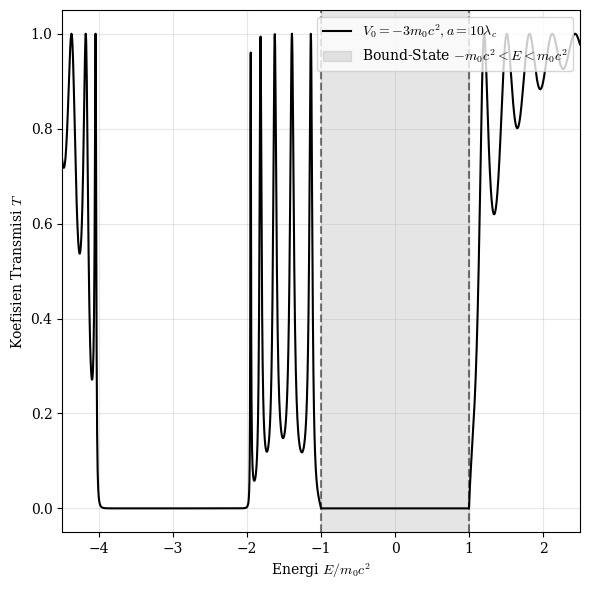

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def transmission_coefficient(E, V0=-3.0, a=10.0):
    """
    Calculate the transmission coefficient T for a Dirac particle
    scattered by a 1D square well.

    E : Energy of the particle (in units of m_0 * c^2)
    V0: Depth of the potential well (in units of m_0 * c^2)
    a : Width of the well (in units of lambda_c)
    """
    # Inside the mass gap (-m_0*c^2 to m_0*c^2), transmission is typically zero for this setup
    if abs(E) < 1.0:
        return 0.0

    # Kinematic matching factor G (sometimes denoted as gamma)
    G = ((E - 1.0) / (E + 1.0)) * ((E - V0 + 1.0) / (E - V0 - 1.0))

    diff_sq = (E - V0)**2

    # Check if the momentum inside the well is real or imaginary
    if diff_sq > 1.0:
        # Real momentum (Oscillatory transmission / resonances)
        X = a * np.sqrt(diff_sq - 1.0)
        T = 1.0 / (1.0 + ((1.0 - G)**2 / (4.0 * G)) * np.sin(X)**2)
    else:
        # Imaginary momentum (Exponential decay inside the well)
        Y = a * np.sqrt(1.0 - diff_sq)
        T = 1.0 / (1.0 - ((1.0 - G)**2 / (4.0 * G)) * np.sinh(Y)**2)

    return T

# Generate energy values (avoiding exactly 1.0 and -1.0 to prevent division by zero)
E_vals = np.linspace(-4.5, 2.5, 2000)
T_vals = np.array([transmission_coefficient(e) for e in E_vals])

# Plot setup
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(E_vals, T_vals, 'k-', label=r'$V_0 = -3 m_0 c^2, a = 10 \lambda_c$')

# Highlight the mass gap [-m_0*c^2, +m_0*c^2]
ax.axvline(x=1.0, color='k', linestyle='--', alpha=0.5)
ax.axvline(x=-1.0, color='k', linestyle='--', alpha=0.5)
ax.axvspan(-1.0, 1.0, color='gray', alpha=0.2, label=r'Bound-State $-m_0 c^2 < E < m_0 c^2$')

# Formatting the plot to match textbook figures
#ax.set_title('Transmission Coefficient of a Dirac Particle in a Square Well')
ax.set_xlabel(r'Energi $E / m_0 c^2$')
ax.set_ylabel(r'Koefisien Transmisi $T$')
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(-4.5, 2.5)

ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Display the plot
plt.tight_layout()
plt.show()

## Rentang Energi Akibat Pengaruh Kopling Potensial Vektor

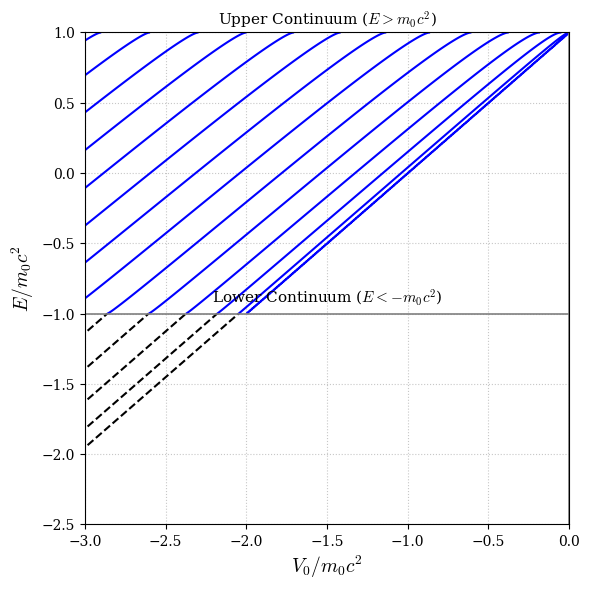

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters in natural units (hbar = c = m_0 = 1)
a = 10.0

# 1. Calculate Bound States (-1 <= E <= 1)
# We will use a meshgrid and contour plot to implicitly solve the transcendental equation
V0_vals = np.linspace(-3.5, 0.0, 1000)
E_vals = np.linspace(-1.0, 1.0, 1000)
V0, E = np.meshgrid(V0_vals, E_vals)

# Using complex numbers ensures stability when expressions inside roots become negative
kappa = np.sqrt(1.0 - E**2 + 0j)
p2 = np.sqrt((E - V0)**2 - 1.0 + 0j)

# The bound state equation: p2 * cot(p2*a) + E*V0/kappa + kappa = 0
# Multiplied by (kappa * sin(p2*a)) to remove singularities for the contour solver
eq_bound = kappa * p2 * np.cos(p2 * a) + (E * V0 + kappa**2) * np.sin(p2 * a)

plt.figure(figsize=(6, 6))

# Plot bound state curves using matplotlib's contour finder at level 0
plt.contour(V0_vals, E_vals, np.real(eq_bound), levels=[0], colors='blue', linewidths=1.5)

# 2. Calculate Dived States / Resonances (E < -1)
# From the text, resonances occur when transmission T=1, simplifying to p2 * a = n * pi
n_max = 6
for n in range(1, n_max + 1):
    # Find the critical potential depth where this state hits E = -1
    V0_critical = -1.0 - np.sqrt(1.0 + (n * np.pi / a)**2)

    # Generate potential depths deeper than the critical threshold
    V0_dived = np.linspace(-3.5, V0_critical, 100)

    # Calculate the resulting resonance energy
    E_dived = V0_dived + np.sqrt(1.0 + (n * np.pi / a)**2)

    # Plot as dashed lines
    plt.plot(V0_dived, E_dived, 'k--', linewidth=1.5)

# Formatting the plot to replicate Figure 9.4
plt.xlim(-3.0, 0.0)
plt.ylim(-2.5, 1.0)
plt.xlabel(r'$V_0 / m_0 c^2$', fontsize=14)
plt.ylabel(r'$E / m_0 c^2$', fontsize=14)
#plt.title(r'Eigenvalue spectrum for a 1D square well ($a = 10 \lambda_c$)', fontsize=14)

# Draw boundaries of the upper and lower continuums
plt.axhline(1.0, color='gray', linestyle='-', linewidth=1.2)
plt.axhline(-1.0, color='gray', linestyle='-', linewidth=1.2)
plt.axvline(0.0, color='gray', linestyle='-', linewidth=1.2)

# Text Annotations
plt.text(-1.5, 1.05, 'Upper Continuum ($E > m_0 c^2$)', ha='center', fontsize=11)
plt.text(-1.5, -0.92, 'Lower Continuum ($E < -m_0 c^2$)', ha='center', fontsize=11)

# Set axes properties
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

# Render plot
plt.show()

## Rentang Energi Akibat Pengaruh Potensial Skalar

/tmp/ipykernel_4648/3348399164.py:24: RuntimeWarning: invalid value encountered in sqrt
  k2 = np.sqrt((1 + V0)**2 - E**2)


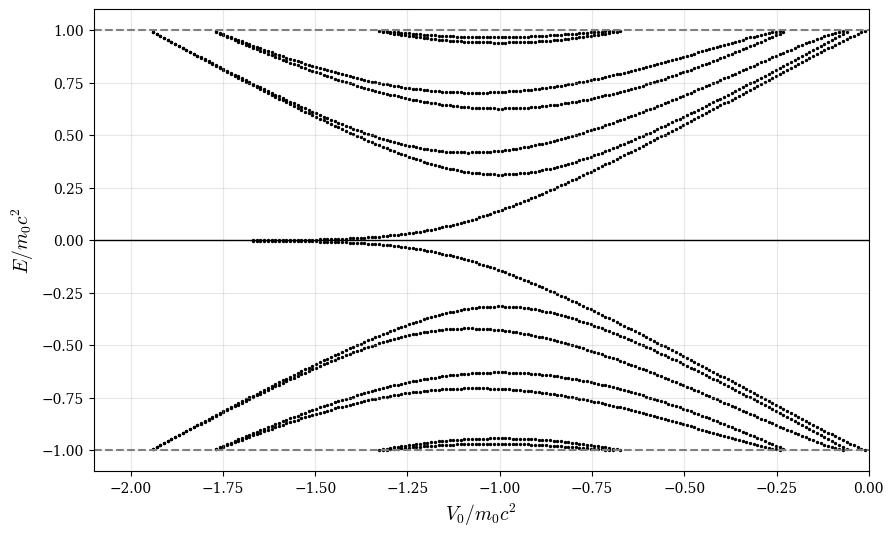

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

# Constants in natural units (m0 = c = hbar = 1)
a = 10.0  # Width of the square well (10 Compton wavelengths)

def kappa1(E):
    """Decay constant outside the well."""
    return np.sqrt(1 - E**2)

def rhs(E, V0):
    """Right-hand side of the transcendental equations."""
    k1 = kappa1(E)
    return -(V0 / k1 + k1)

def eq_real(E, V0):
    """Transcendental equation for real momentum p2."""
    p2 = np.sqrt(E**2 - (1 + V0)**2)
    return p2 * 1.0 / np.tan(p2 * a) - rhs(E, V0)

def eq_imag(E, V0):
    """Transcendental equation for imaginary momentum p2 (kappa2)."""
    k2 = np.sqrt((1 + V0)**2 - E**2)
    return k2 * 1.0 / np.tanh(k2 * a) - rhs(E, V0)

def find_eigenvalues(V0):
    """Find all valid energy eigenvalues E for a given potential V0."""
    energies = []
    # Search grid for E between 0 and 1 (symmetric, so we only search positive E)
    E_scan = np.linspace(0.001, 0.999, 1000)

    for i in range(len(E_scan) - 1):
        E_val = E_scan[i]
        E_next = E_scan[i+1]

        # Determine which equation to use based on the argument of the square root
        if E_val**2 > (1 + V0)**2:
            func = eq_real
        else:
            func = eq_imag

        try:
            # Check for zero crossings
            if func(E_val, V0) * func(E_next, V0) < 0:
                sol = root_scalar(func, args=(V0,), bracket=[E_val, E_next], method='brentq')
                if sol.converged:
                    energies.append(sol.root)
        except ValueError:
            pass

    return energies

# Generate data for the plot
V0_vals = np.linspace(0, -2, 200)
all_E = []
all_V0 = []

for V0 in V0_vals:
    E_roots = find_eigenvalues(V0)
    for E in E_roots:
        all_E.append(E)
        all_V0.append(V0)
        # Exploit symmetry: If E is a bound state, -E is also a bound state
        all_E.append(-E)
        all_V0.append(V0)

# Plotting the spectrum
plt.figure(figsize=(10, 6))
plt.scatter(all_V0, all_E, color='black', s=2)
plt.xlim(0, -2.1)
plt.ylim(-1.1, 1.1)
plt.axhline(0, color='black', linewidth=1)
plt.axhline(1, color='gray', linestyle='--')
plt.axhline(-1, color='gray', linestyle='--')
plt.xlabel(r'$V_0 / m_0 c^2$', fontsize=14)
plt.ylabel(r'$E / m_0 c^2$', fontsize=14)

plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.show()

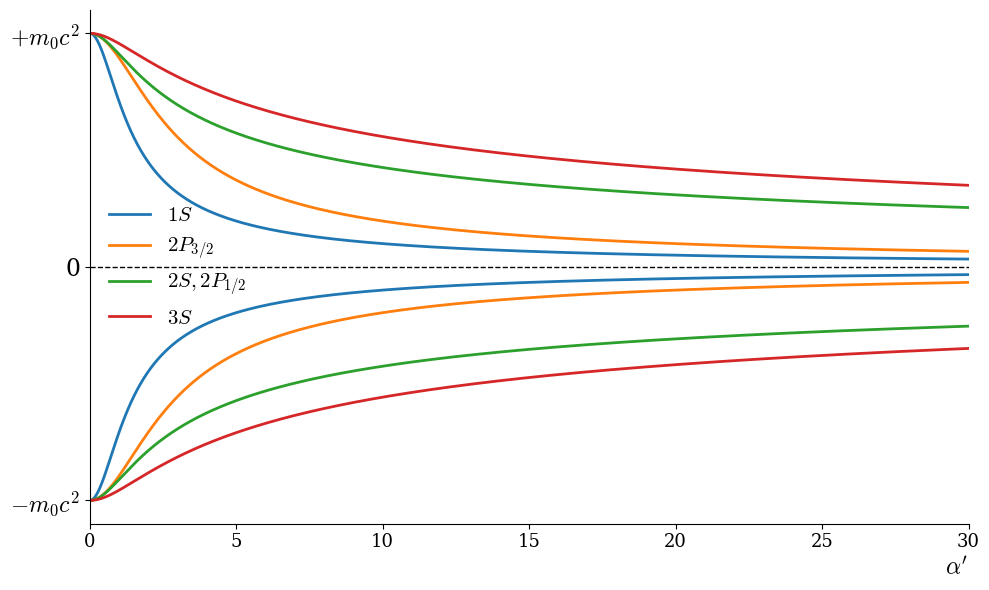

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range for the scalar coupling constant alpha'
alpha_prime = np.linspace(0, 30, 3000)

# Define the energy functions E/m_0c^2 for each state
E_1s = 1 / np.sqrt(1 + alpha_prime**2)
E_2p32 = 2 / np.sqrt(4 + alpha_prime**2)
E_2s_2p12 = np.sqrt(1 - alpha_prime**2 / (1 + np.sqrt(1 + alpha_prime**2))**2)
E_3s = np.sqrt(1 - alpha_prime**2 / (2 + np.sqrt(1 + alpha_prime**2))**2)

# Set up the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Define a distinct color for each state pair
color_1s = '#1f77b4'       # Blue
color_2p32 = '#ff7f0e'     # Orange
color_2s2p12 = '#2ca02c'   # Green
color_3s = '#d62728'       # Red

# Plot positive branches (Particles) - these get the labels for the legend
ax.plot(alpha_prime, E_1s, label=r'$1S$', color=color_1s, linewidth=2)
ax.plot(alpha_prime, E_2p32, label=r'$2P_{3/2}$', color=color_2p32, linewidth=2)
ax.plot(alpha_prime, E_2s_2p12, label=r'$2S, 2P_{1/2}$', color=color_2s2p12, linewidth=2)
ax.plot(alpha_prime, E_3s, label=r'$3S$', color=color_3s, linewidth=2)

# Plot negative branches (Antiparticles) - no labels so they don't duplicate in the legend
ax.plot(alpha_prime, -E_1s, color=color_1s, linewidth=2)
ax.plot(alpha_prime, -E_2p32, color=color_2p32, linewidth=2)
ax.plot(alpha_prime, -E_2s_2p12, color=color_2s2p12, linewidth=2)
ax.plot(alpha_prime, -E_3s, color=color_3s, linewidth=2)

# Formatting axes
ax.set_xlim(0, max(alpha_prime))
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel(r'$\alpha^\prime$', fontsize=17, loc='right')
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels([r'$-m_0c^2$', '0', r'$+m_0c^2$'], fontsize=17)
ax.tick_params(axis='x', labelsize=13) # Increase x-axis tick label size

# Spine formatting for a clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(0, color='black', linewidth=1, linestyle='--') # Center line at E=0

# Add the legend
# loc='center right' places it neatly between the converging lines
ax.legend(loc='center left', frameon=False, fontsize=15)

plt.tight_layout()
plt.show()

In [ ]:
OUTPUT_DIR = "/content/drive/MyDrive/OszavlaDrive/Dokumen/Data_Komputasi/"
NOTEBOOK_PATH = "/content/drive/MyDrive/Colab Notebooks/Fungsi_Eigen_Nilai_Eigen_Koefisien_Transmisi.ipynb"

!jupyter nbconvert --to latex "{NOTEBOOK_PATH}" --output-dir="{OUTPUT_DIR}"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Fungsi_Eigen_Nilai_Eigen_Koefisien_Transmisi.ipynb to latex
[NbConvertApp] Support files will be in Fungsi_Eigen_Nilai_Eigen_Koefisien_Transmisi_files/
[NbConvertApp] Making directory /content/drive/MyDrive/OszavlaDrive/Dokumen/Data_Komputasi/Fungsi_Eigen_Nilai_Eigen_Koefisien_Transmisi_files
[NbConvertApp] Writing 283542 bytes to /content/drive/MyDrive/OszavlaDrive/Dokumen/Data_Komputasi/Fungsi_Eigen_Nilai_Eigen_Koefisien_Transmisi.tex
